In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

RAW_DIR = Path.home() / 'Desktop/repos/solar-grid/ml/data/raw'

df = pd.read_csv(RAW_DIR / 'prices_pl.csv', parse_dates=['timestamp'])

# Convert UTC to Polish local time
df['timestamp']   = df['timestamp'].dt.tz_convert('Europe/Warsaw')
df['hour']        = df['timestamp'].dt.hour
df['month']       = df['timestamp'].dt.month
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['date']        = df['timestamp'].dt.date

print(f"Rows: {len(df)}")
print(f"Date range: {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"Negative price hours: {(df['price_pln_mwh'] < 0).sum()}")
print(f"Price > 1000 PLN/MWh hours: {(df['price_pln_mwh'] > 1000).sum()}")
df.head()

Rows: 9420
Date range: 2025-03-01 00:00:00+01:00 → 2026-03-30 00:00:00+02:00
Negative price hours: 346
Price > 1000 PLN/MWh hours: 210


,timestamp,price_eur_mwh,price_pln_mwh,hour,month,day_of_week,date
0,2025-03-01 00:00:00+01:00,128.34,545.4450,0,3,5,2025-03-01
1,2025-03-01 01:00:00+01:00,120.48,512.0400,1,3,5,2025-03-01
2,2025-03-01 02:00:00+01:00,117.15,497.8875,2,3,5,2025-03-01
3,2025-03-01 03:00:00+01:00,112.42,477.7850,3,3,5,2025-03-01
4,2025-03-01 04:00:00+01:00,109.94,467.2450,4,3,5,2025-03-01


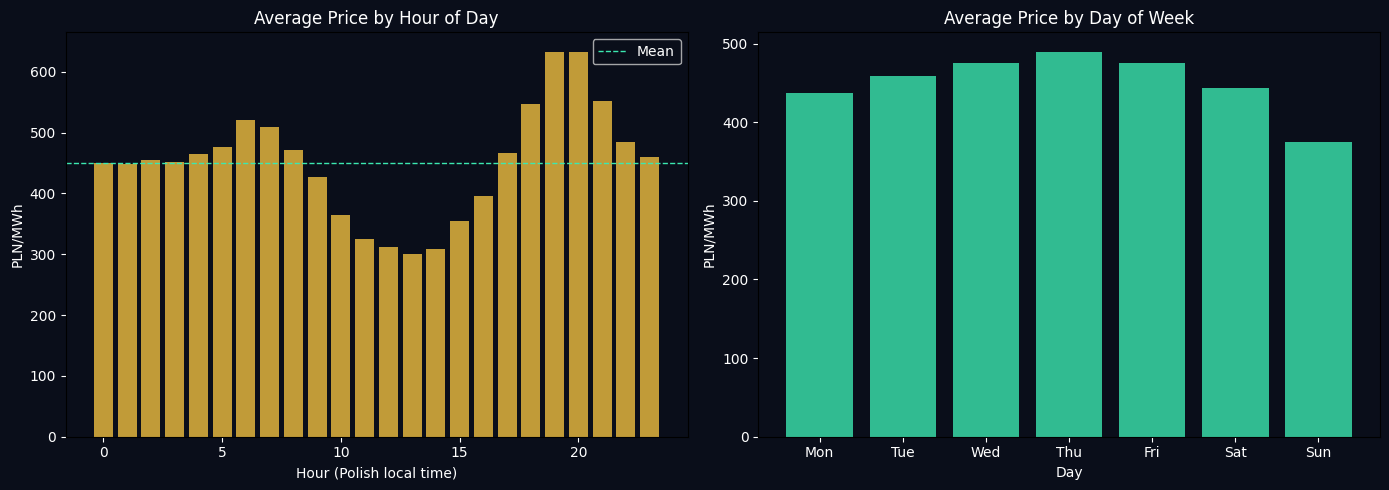

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0a0e1a')

hourly = df.groupby('hour')['price_pln_mwh'].mean()
axes[0].bar(hourly.index, hourly.values, color='#f0c040', alpha=0.8)
axes[0].set_title('Average Price by Hour of Day', color='white')
axes[0].set_xlabel('Hour (Polish local time)', color='white')
axes[0].set_ylabel('PLN/MWh', color='white')
axes[0].set_facecolor('#0a0e1a')
axes[0].tick_params(colors='white')
axes[0].axhline(df['price_pln_mwh'].mean(), color='#3be8b0',
                linewidth=1, linestyle='--', label='Mean')
axes[0].legend(facecolor='#0a0e1a', labelcolor='white')

days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
daily = df.groupby('day_of_week')['price_pln_mwh'].mean()
axes[1].bar(range(7), daily.values, color='#3be8b0', alpha=0.8)
axes[1].set_title('Average Price by Day of Week', color='white')
axes[1].set_xlabel('Day', color='white')
axes[1].set_ylabel('PLN/MWh', color='white')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(days)
axes[1].set_facecolor('#0a0e1a')
axes[1].tick_params(colors='white')

plt.tight_layout()
plt.show()

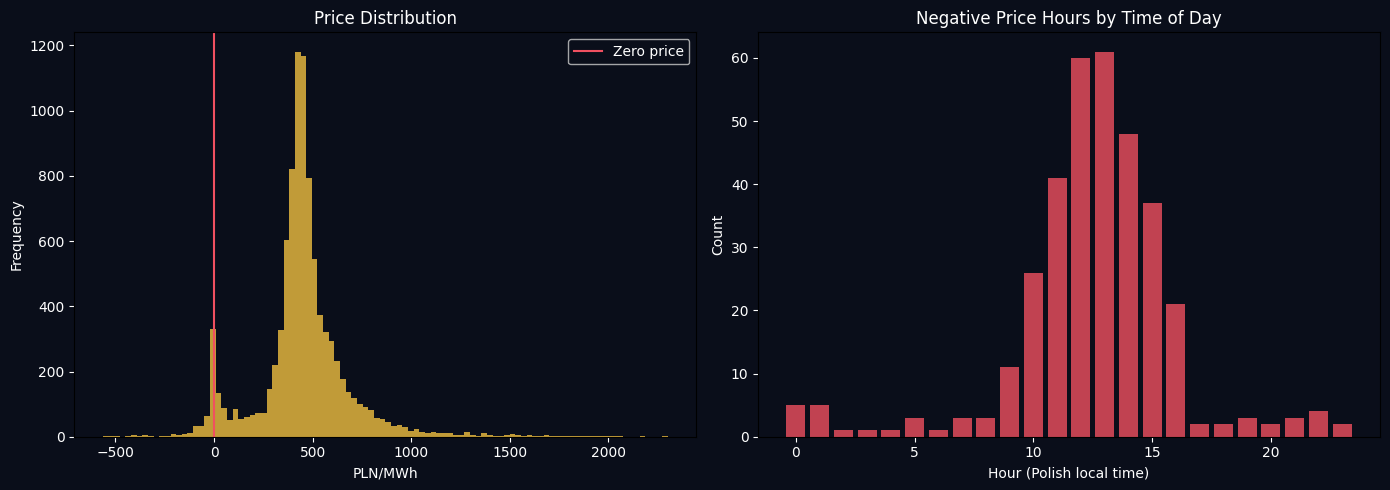

Negative prices: 346 hours (3.7%)
Most common negative price hour: 13:00
Worst negative price: -565 PLN/MWh


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0a0e1a')

axes[0].hist(df['price_pln_mwh'], bins=100, color='#f0c040',
             alpha=0.8, edgecolor='none')
axes[0].set_title('Price Distribution', color='white')
axes[0].set_xlabel('PLN/MWh', color='white')
axes[0].set_ylabel('Frequency', color='white')
axes[0].set_facecolor('#0a0e1a')
axes[0].tick_params(colors='white')
axes[0].axvline(0, color='#f05060', linewidth=1.5, label='Zero price')
axes[0].legend(facecolor='#0a0e1a', labelcolor='white')

negative = df[df['price_pln_mwh'] < 0]
neg_by_hour = negative.groupby('hour').size()
axes[1].bar(neg_by_hour.index, neg_by_hour.values, color='#f05060', alpha=0.8)
axes[1].set_title('Negative Price Hours by Time of Day', color='white')
axes[1].set_xlabel('Hour (Polish local time)', color='white')
axes[1].set_ylabel('Count', color='white')
axes[1].set_facecolor('#0a0e1a')
axes[1].tick_params(colors='white')

plt.tight_layout()
plt.show()

print(f"Negative prices: {len(negative)} hours ({len(negative)/len(df)*100:.1f}%)")
print(f"Most common negative price hour: {neg_by_hour.idxmax()}:00")
print(f"Worst negative price: {negative['price_pln_mwh'].min():.0f} PLN/MWh")

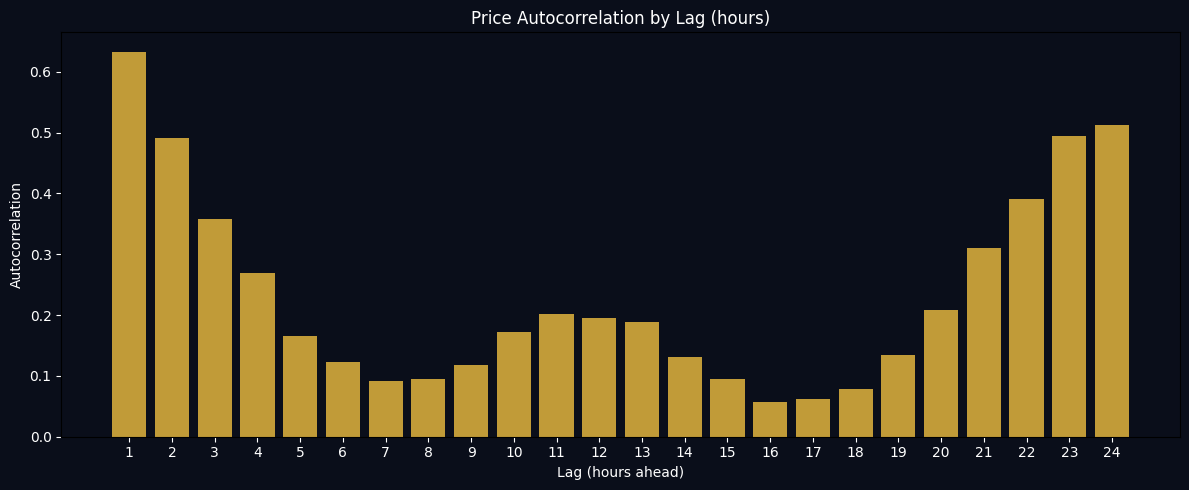

Autocorrelation at key lags:
  Lag  1h: 0.633
  Lag  2h: 0.491
  Lag  3h: 0.359
  Lag  6h: 0.122
  Lag 12h: 0.195
  Lag 24h: 0.513


In [7]:
lags = range(1, 25)
correlations = [df['price_pln_mwh'].autocorr(lag=lag) for lag in lags]

plt.figure(figsize=(12, 5), facecolor='#0a0e1a')
plt.bar(lags, correlations, color='#f0c040', alpha=0.8)
plt.title('Price Autocorrelation by Lag (hours)', color='white')
plt.xlabel('Lag (hours ahead)', color='white')
plt.ylabel('Autocorrelation', color='white')
plt.tick_params(colors='white')
plt.gca().set_facecolor('#0a0e1a')
plt.axhline(0, color='white', linewidth=0.5)
plt.xticks(lags)
plt.tight_layout()
plt.show()

print("Autocorrelation at key lags:")
for lag in [1, 2, 3, 6, 12, 24]:
    corr = df['price_pln_mwh'].autocorr(lag=lag)
    print(f"  Lag {lag:2d}h: {corr:.3f}")